In [50]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [51]:
# Master
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')
promotions = pd.read_csv('promotions.csv')
geography = pd.read_csv('geography.csv')
# transaction
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')    
shipment = pd.read_csv('shipments.csv')
returns = pd.read_csv('returns.csv')
# Analitical
sales = pd.read_csv('sales.csv')
# Operational
inventory = pd.read_csv('inventory.csv')
web_traffic = pd.read_csv('web_traffic.csv')

Tạo đặc trưng

In [52]:
import pandas as pd
import numpy as np

# 1. TẢI DỮ LIỆU & ĐỒNG NHẤT CỘT THỜI GIAN

df_all = pd.read_csv('sales.csv')
df_all['Date'] = pd.to_datetime(df_all['Date'])

orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
web_traffic = pd.read_csv('web_traffic.csv')

# Đổi định dạng ngày để dễ merge
orders['order_date'] = pd.to_datetime(orders['order_date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])


# 2. FEATURE TỪ DỮ LIỆU GIAO DỊCH (TRANSACTION)

transactions = pd.merge(order_items, orders, on='order_id', how='left')


daily_transactions = transactions.groupby('order_date').agg(
    total_quantity_sold=('quantity', 'sum'),
    total_discount_given=('discount_amount', 'sum'),
    unique_orders=('order_id', 'nunique')
).reset_index()

# Đổi tên cột để merge với bảng sales chính
daily_transactions.rename(columns={'order_date': 'Date'}, inplace=True)

# Gắn vào bảng dữ liệu chính
df_all = pd.merge(df_all, daily_transactions, on='Date', how='left')


# 3. FEATURE TỪ LƯU LƯỢNG TRUY CẬP (OPERATIONAL)

daily_traffic = web_traffic.groupby('date').agg(
    total_sessions=('sessions', 'sum'),
    total_page_views=('page_views', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean')
).reset_index()

daily_traffic.rename(columns={'date': 'Date'}, inplace=True)


df_all = pd.merge(df_all, daily_traffic, on='Date', how='left')


# 4. ĐẶC TRƯNG THỜI GIAN (TIME-BASED FEATURES)

df_all['day_of_week'] = df_all['Date'].dt.dayofweek
df_all['day_of_month'] = df_all['Date'].dt.day
df_all['month'] = df_all['Date'].dt.month
df_all['quarter'] = df_all['Date'].dt.quarter
df_all['year'] = df_all['Date'].dt.year
df_all['is_weekend'] = df_all['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)



# 6. XỬ LÝ MISSING VALUES & XUẤT DỮ LIỆU

cols_to_fill_zero = ['total_quantity_sold', 'total_discount_given', 'unique_orders', 
                     'total_sessions', 'total_page_views']
df_all.loc[df_all['Date'].dt.year == 2012, cols_to_fill_zero] = np.nan

In [53]:
df_all.to_csv('df_all.csv', index=False, encoding='utf-8')

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. TẠO BỘ KHUNG THỜI GIAN (TRAIN + TEST)
# ==========================================
# Đọc file train
sales_train = pd.read_csv('sales.csv')
sales_train['Date'] = pd.to_datetime(sales_train['Date'])

# Đọc file mẫu nộp bài (để lấy danh sách ngày của tập Test)
sales_test = pd.read_csv('sample_submission.csv')
sales_test['Date'] = pd.to_datetime(sales_test['Date'])

# Nối dọc để tạo khung xương không rớt ngày nào từ 2012 đến 2024
df_base = pd.concat([sales_train, sales_test], ignore_index=True)
df_base = df_base.sort_values('Date').reset_index(drop=True)

# --- BỔ SUNG ĐẶC TRƯNG NGÀY LỄ (HOLIDAYS & SALE EVENTS) ---
# Tạo các mảng ngày cố định hàng năm
def assign_holiday_flags(df):
    df['is_holiday'] = 0
    df['is_super_sale'] = 0
    df['is_payday'] = 0
    
    # Lấy ngày và tháng
    month = df['Date'].dt.month
    day = df['Date'].dt.day
    
    # 1. Các ngày lễ lớn của Việt Nam (30/4, 1/5, 2/9, 1/1, 14/2, 8/3, 1/6, 20/10)
    holiday_mask = (
        ((day == 30) & (month == 4)) | 
        ((day == 1) & (month == 5)) | 
        ((day == 2) & (month == 9)) |
        ((day == 1) & (month == 1)) |
        ((day == 14) & (month == 2)) |
        ((day == 8) & (month == 3)) |
        ((day == 1) & (month == 6)) |
        ((day == 20) & (month == 10))
    )
    df.loc[holiday_mask, 'is_holiday'] = 1
    
    # Gắn cờ luôn cho các ngày cận Lễ (Hành vi mua sắm trước Lễ)
    df['is_near_holiday'] = df['is_holiday'].shift(-1).fillna(0) + df['is_holiday'].shift(-2).fillna(0)
    df['is_near_holiday'] = df['is_near_holiday'].apply(lambda x: 1 if x > 0 else 0)

    # 2. Các ngày Siêu Sale Thương mại điện tử (11/11, 12/12, Black Friday)
    # Tạm gán Black Friday vào khoảng 24-27 tháng 11
    super_sale_mask = (
        ((day == 11) & (month == 11)) | 
        ((day == 12) & (month == 12)) |
        ((day >= 24) & (day <= 27) & (month == 11))
    )
    df.loc[super_sale_mask, 'is_super_sale'] = 1
    
    # 3. Hiệu ứng ngày nhận lương (Thường mua sắm mạnh vào ngày 1-5 và 28-31 hàng tháng)
    payday_mask = (day <= 5) | (day >= 28)
    df.loc[payday_mask, 'is_payday'] = 1
    
    return df
# ==========================================
# 2. XÂY DỰNG TỪ ĐIỂN ĐẶC TRƯNG (DF_CALENDAR)
# ==========================================
df_calendar = pd.DataFrame({'Date': df_base['Date'].unique()})

# --- 2.1 Đặc trưng Thời gian & Mùa vụ (Lượng giác) ---
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['is_weekend'] = df_calendar['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

day_of_year = df_calendar['Date'].dt.dayofyear
T = 365.25
df_calendar['sin_365'] = np.sin(2 * np.pi * day_of_year / T)
df_calendar['cos_365'] = np.cos(2 * np.pi * day_of_year / T)

# --- 2.2 Đặc trưng Độ lớn tệp khách hàng ---
customers = pd.read_csv('customers.csv')
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
daily_signups = customers.groupby('signup_date').size().reset_index(name='new_users')
daily_signups.rename(columns={'signup_date': 'Date'}, inplace=True)

df_calendar = pd.merge(df_calendar, daily_signups, on='Date', how='left')
df_calendar['new_users'] = df_calendar['new_users'].fillna(0)
df_calendar['cumulative_customer_base'] = df_calendar['new_users'].cumsum()
df_calendar.drop(columns=['new_users'], inplace=True)

# --- 2.3 Đặc trưng Sức ép Khuyến mãi ---
promos = pd.read_csv('promotions.csv')
promos['start_date'] = pd.to_datetime(promos['start_date'])
promos['end_date'] = pd.to_datetime(promos['end_date'])

promo_stats = []
for current_date in df_calendar['Date']:
    active = promos[(promos['start_date'] <= current_date) & (promos['end_date'] >= current_date)]
    if len(active) > 0:
        max_discount = active['discount_value'].max()
        is_stackable = 1 if active['stackable_flag'].sum() > 0 else 0
    else:
        max_discount = 0
        is_stackable = 0
    promo_stats.append({
        'Date': current_date,
        'active_promos_count': len(active),
        'max_discount_depth': max_discount,
        'is_stackable_day': is_stackable
    })
df_calendar = pd.merge(df_calendar, pd.DataFrame(promo_stats), on='Date', how='left')
df_calendar = assign_holiday_flags(df_calendar)
df_calendar['holiday_promo_interaction'] = df_calendar['is_holiday'] * df_calendar['max_discount_depth']
df_calendar['payday_promo_interaction'] = df_calendar['is_payday'] * df_calendar['max_discount_depth']

# --- 2.4 Đặc trưng Traffic (Chống Leakage bằng Giá trị Lịch sử) ---
web_traffic = pd.read_csv('web_traffic.csv')
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic['pages_per_session'] = web_traffic['page_views'] / web_traffic['sessions']
web_traffic['week_of_year'] = web_traffic['date'].dt.isocalendar().week
web_traffic['day_of_week'] = web_traffic['date'].dt.dayofweek

historical_traffic = web_traffic.groupby(['week_of_year', 'day_of_week']).agg(
    expected_sessions=('sessions', 'mean'),
    expected_unique_visitors=('unique_visitors', 'mean'),
    expected_bounce_rate=('bounce_rate', 'mean'),
    expected_pages_per_session=('pages_per_session', 'mean')
).reset_index()

df_calendar['week_of_year'] = df_calendar['Date'].dt.isocalendar().week
df_calendar = pd.merge(df_calendar, historical_traffic, on=['week_of_year', 'day_of_week'], how='left')
df_calendar.drop(columns=['week_of_year'], inplace=True)

# Lấp đầy các ngày không có lịch sử (như năm 2012) bằng trung vị
cols_traffic = ['expected_sessions', 'expected_unique_visitors', 'expected_bounce_rate', 'expected_pages_per_session']
for col in cols_traffic:
    df_calendar[col] = df_calendar[col].fillna(df_calendar[col].median())

# ==========================================
# 3. GỘP DATA VÀ CHIA TẬP TRAIN/TEST
# ==========================================
# Gộp feature vào khung base
df_final = pd.merge(df_base, df_calendar, on='Date', how='left')

# Chia tập dựa trên mốc 01/01/2023 của đề bài
train_mask = df_final['Date'] < '2023-01-01'
test_mask = df_final['Date'] >= '2023-01-01'

X_train = df_final[train_mask].copy()
X_test = df_final[test_mask].copy()

# Tách nhãn (Target)
y_train_revenue = X_train.pop('Revenue')
y_train_cogs = X_train.pop('COGS')

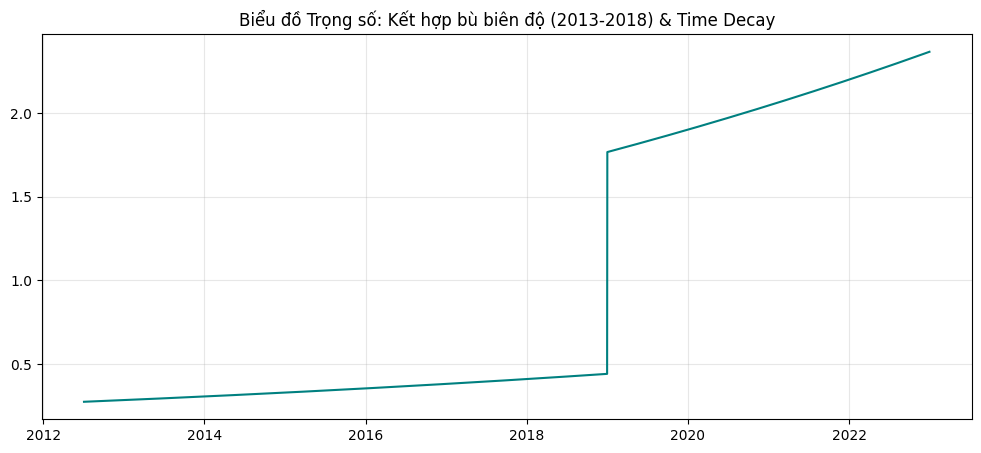

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_advanced_weights(df, k=0.0001):
    # Khởi tạo mảng trọng số bằng 1.0
    weights = np.ones(len(df))
    
    # --- TẦNG 1: BÙ TRỪ BIÊN ĐỘ (AMPLITUDE BALANCING) ---
    # Giai đoạn biên độ x2 -> Phương sai x4 -> Trọng số phải chia 4 (0.25)
    mask_old = df['Date'].dt.year <= 2018
    weights[mask_old] = 0.25 
    
    # --- TẦNG 2: SUY GIẢM THỜI GIAN (TIME DECAY) ---
    max_date = df['Date'].max()
    days_diff = (max_date - df['Date']).dt.days
    decay_weights = np.exp(-k * days_diff)
    
    # --- GỘP TRỌNG SỐ ---
    final_weights = weights * decay_weights
    
    # Chuẩn hóa về trung bình = 1 để LightGBM không bị "shock" scale
    return final_weights / final_weights.mean()

# Áp dụng
sample_weights = calculate_advanced_weights(X_train, k=0.0002)

# Trực quan hóa để kiểm tra
plt.figure(figsize=(12, 5))
plt.plot(X_train['Date'], sample_weights, color='teal')
plt.title('Biểu đồ Trọng số: Kết hợp bù biên độ (2013-2018) & Time Decay')
plt.grid(True, alpha=0.3)
plt.show()

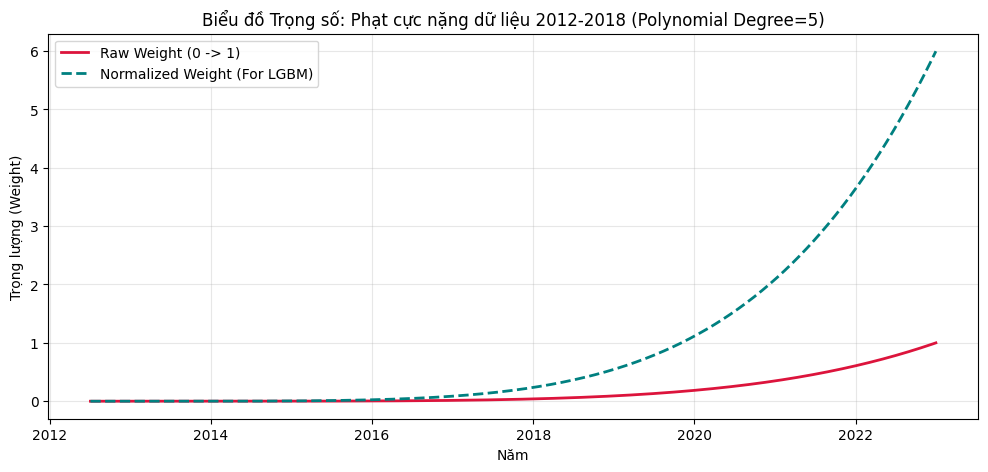

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử bạn đang có cột 'Date' trong X_train (hoặc df_final)
# Nếu bạn đã drop 'Date' ra khỏi X_train, hãy lấy lại từ df_final[train_mask]
dates = df_final[train_mask]['Date'] if 'df_final' in locals() else X_train['Date']

max_date = dates.max()
days_diff = (max_date - dates).dt.days

# ==========================================
# CÁCH 1: DÙNG HÀM MŨ VỚI ĐỘ DỐC CAO HƠN
# ==========================================
# k = 0.0015 -> Năm 2012 (cách 3650 ngày) trọng số sẽ là e^(-5.47) ≈ 0.004 (gần như bằng 0)
# Năm 2019 (cách ~1100 ngày) trọng số ≈ 0.19
k_high = 0.0015
weights_exponential = np.exp(-k_high * days_diff)

# ==========================================
# CÁCH 2: DÙNG ĐƯỜNG CONG ĐA THỨC (POLYNOMIAL) - KHUYÊN DÙNG
# ==========================================
# Bước 1: Đưa mốc thời gian về dải [0, 1] (0 là 2012, 1 là 2022)
max_days = days_diff.max()
time_ratio = 1 - (days_diff / max_days) 

# Bước 2: Mũ hóa (Lũy thừa 4 hoặc 5). 
# Bằng cách này, 2012 -> 0^5 = 0; 2017 (0.5) -> 0.5^5 = 0.03; 2022 -> 1^5 = 1
power_degree = 5
weights_poly = time_ratio ** power_degree

# ==========================================
# CHỌN TRỌNG SỐ VÀ CHUẨN HÓA CHO LIGHTGBM
# ==========================================
# Chọn Cách 2 (Polynomial)
raw_weights = weights_poly 

# BẮT BUỘC CHUẨN HÓA (Để trung bình = 1, giúp LightGBM không bị loạn Learning Rate)
sample_weights = raw_weights / raw_weights.mean()

# ==========================================
# TRỰC QUAN HÓA KIỂM TRA ĐƯỜNG CONG
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(dates, raw_weights, color='crimson', linewidth=2, label='Raw Weight (0 -> 1)')
plt.plot(dates, sample_weights, color='teal', linewidth=2, linestyle='--', label='Normalized Weight (For LGBM)')
plt.title('Biểu đồ Trọng số: Phạt cực nặng dữ liệu 2012-2018 (Polynomial Degree=5)')
plt.xlabel('Năm')
plt.ylabel('Trọng lượng (Weight)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
X_test.drop(columns=['Revenue', 'COGS'], inplace=True, errors='ignore')

# Bỏ cột Date trước khi cho vào LightGBM, nhưng lưu lại ngày của test set để ráp vào file submission
X_train.drop(columns=['Date'], inplace=True)
test_dates = X_test.pop('Date')

print("Hoàn tất xử lý!")
print(f"Kích thước X_train: {X_train.shape} | Số dòng nhãn: {len(y_train_revenue)}")
print(f"Kích thước X_test: {X_test.shape} | Đã chuẩn bị sẵn sàng để dự báo")

Hoàn tất xử lý!
Kích thước X_train: (3833, 13) | Số dòng nhãn: 3833
Kích thước X_test: (548, 13) | Đã chuẩn bị sẵn sàng để dự báo


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1. HẠ SCALE DỮ LIỆU CŨ (DOWNSCALING) ĐỂ CHỐNG NHIỄU
# ==========================================
print("--- Đang chuẩn hóa (Downscale) biên độ dữ liệu 2012-2018 ---")
# Lấy mảng thời gian từ dữ liệu Train (Giả sử bạn dùng X_train gốc)
dates = df_final[train_mask]['Date'] if 'df_final' in locals() else pd.to_datetime(sales_train['Date'])
mask_old = dates.dt.year < 2019
mask_new = dates.dt.year >= 2019

# Hạ scale Revenue
ratio_rev = y_train_revenue[mask_old].mean() / y_train_revenue[mask_new].mean()
y_train_rev_adj = y_train_revenue.copy()
y_train_rev_adj[mask_old] = y_train_rev_adj[mask_old] / ratio_rev

# Hạ scale COGS
ratio_cogs = y_train_cogs[mask_old].mean() / y_train_cogs[mask_new].mean()
y_train_cogs_adj = y_train_cogs.copy()
y_train_cogs_adj[mask_old] = y_train_cogs_adj[mask_old] / ratio_cogs

# ==========================================
# 2. HÀM TÌM THAM SỐ VỚI TIME SERIES SPLIT TỐI ƯU
# ==========================================
def tune_hyperparameters_tscv(X, y, target_name, n_trials=50):
    print(f"--- Săn tham số {target_name} (TimeSeriesSplit | Test_size=548 | Log Transform) ---")
    
    y_log = np.log1p(y) # Nén biên độ bằng Log
    
    # THIẾT LẬP TIMESERIESSPLIT CHUẨN:
    # 5 splits, mỗi fold kiểm định đúng 548 ngày (bằng độ dài tập Test thực tế)
    tscv = TimeSeriesSplit(n_splits=5, test_size=548)
    
    def objective(trial):
        param = {
            'objective': 'huber', # Dùng huber kháng nhiễu tốt hơn
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'random_state': 42,
            'verbose': -1,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 256), 
            'max_depth': trial.suggest_int('max_depth', 6, 15),      
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 25), 
            'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 3),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-5, 1.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-5, 1.0, log=True),
            'alpha': trial.suggest_float('alpha', 1.0, 3.0) 
        }

        scores = []
        
        for train_idx, val_idx in tscv.split(X):
            # TimeSeriesSplit trả về index dạng integer (0,1,2..) nên dùng .iloc rất an toàn, không bị lỗi KeyError
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            
            y_tr_log, y_va_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
            y_va_raw = y.iloc[val_idx] # y gốc để tính R2 thật

            model = lgb.LGBMRegressor(**param, n_estimators=1000)
            
            callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
            model.fit(
                X_tr, y_tr_log, 
                eval_set=[(X_va, y_va_log)], 
                callbacks=callbacks
            )
            
            preds_log = model.predict(X_va)
            preds_raw = np.maximum(0, np.expm1(preds_log))
            
            scores.append(r2_score(y_va_raw, preds_raw))
            
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"✓ Best R2 trung bình (5 Folds) cho {target_name}: {study.best_value:.4f}")
    return study.best_params

# ==========================================
# 3. CHẠY TÌM THAM SỐ TRÊN DỮ LIỆU ĐÃ DOWNSCALE
# ==========================================
X_train_run = X_train_pruned if 'X_train_pruned' in locals() else X_train

# Truyền y đã được downscale vào (y_train_rev_adj) thay vì y gốc
best_params_rev = tune_hyperparameters_tscv(X_train_run, y_train_rev_adj, "Revenue", n_trials=50)
best_params_cogs = tune_hyperparameters_tscv(X_train_run, y_train_cogs_adj, "COGS", n_trials=50)

--- Đang chuẩn hóa (Downscale) biên độ dữ liệu 2012-2018 ---
--- Săn tham số Revenue (TimeSeriesSplit | Test_size=548 | Log Transform) ---
✓ Best R2 trung bình (5 Folds) cho Revenue: 0.7468
--- Săn tham số COGS (TimeSeriesSplit | Test_size=548 | Log Transform) ---
✓ Best R2 trung bình (5 Folds) cho COGS: 0.7283


In [58]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1. HẠ SCALE DỮ LIỆU CŨ (DOWNSCALING) ĐỂ CHỐNG NHIỄU
# ==========================================
print("--- Đang chuẩn hóa (Downscale) biên độ dữ liệu 2012-2018 ---")
# Lấy mảng thời gian từ dữ liệu Train
dates = df_final[train_mask]['Date'] if 'df_final' in locals() else pd.to_datetime(sales_train['Date'])
mask_old = dates.dt.year < 2019
mask_new = dates.dt.year >= 2019

# Hạ scale Revenue
ratio_rev = y_train_revenue[mask_old].mean() / y_train_revenue[mask_new].mean()
y_train_rev_adj = y_train_revenue.copy()
y_train_rev_adj[mask_old] = y_train_rev_adj[mask_old] / ratio_rev

# Hạ scale COGS
ratio_cogs = y_train_cogs[mask_old].mean() / y_train_cogs[mask_new].mean()
y_train_cogs_adj = y_train_cogs.copy()
y_train_cogs_adj[mask_old] = y_train_cogs_adj[mask_old] / ratio_cogs

# ==========================================
# 2. HÀM TÌM THAM SỐ VỚI TWEEDIE LOSS
# ==========================================
def tune_hyperparameters_tscv(X, y, target_name, n_trials=50):
    print(f"--- Săn tham số {target_name} (TimeSeriesSplit | Test_size=548 | Tweedie Loss) ---")
    
    # ĐÃ BỎ np.log1p() DO TWEEDIE TỰ ĐỘNG XỬ LÝ LOG-LINK BÊN TRONG MÔ HÌNH
    
    # Thiết lập TimeSeriesSplit chuẩn
    tscv = TimeSeriesSplit(n_splits=5, test_size=548)
    
    def objective(trial):
        param = {
            'objective': 'tweedie', # Đổi sang hàm Tweedie
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9), # Tham số riêng để điều chỉnh phương sai của Tweedie
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'random_state': 42,
            'verbose': -1,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 256), 
            'max_depth': trial.suggest_int('max_depth', 6, 15),      
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 25), 
            'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 3),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-5, 1.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-5, 1.0, log=True)
            # Đã bỏ tham số 'alpha' vì nó chỉ dành cho hàm huber
        }

        scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            
            # Dùng trực tiếp dữ liệu (chưa log) vào trong mô hình
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

            model = lgb.LGBMRegressor(**param, n_estimators=1000)
            
            callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_va, y_va)], 
                callbacks=callbacks
            )
            
            # Kết quả predict tự động sinh ra giá trị thực (không cần expm1)
            preds = model.predict(X_va)
            preds_raw = np.maximum(0, preds)
            
            scores.append(r2_score(y_va, preds_raw))
            
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"✓ Best R2 trung bình (5 Folds) cho {target_name}: {study.best_value:.4f}")
    return study.best_params

# ==========================================
# 3. CHẠY TÌM THAM SỐ TRÊN DỮ LIỆU ĐÃ DOWNSCALE
# ==========================================
X_train_run = X_train_pruned if 'X_train_pruned' in locals() else X_train

# Truyền y đã được downscale vào (y_train_rev_adj) thay vì y gốc
best_params_rev = tune_hyperparameters_tscv(X_train_run, y_train_rev_adj, "Revenue", n_trials=50)
best_params_cogs = tune_hyperparameters_tscv(X_train_run, y_train_cogs_adj, "COGS", n_trials=50)

--- Đang chuẩn hóa (Downscale) biên độ dữ liệu 2012-2018 ---
--- Săn tham số Revenue (TimeSeriesSplit | Test_size=548 | Tweedie Loss) ---
✓ Best R2 trung bình (5 Folds) cho Revenue: 0.7458
--- Săn tham số COGS (TimeSeriesSplit | Test_size=548 | Tweedie Loss) ---
✓ Best R2 trung bình (5 Folds) cho COGS: 0.7312


In [59]:
import json
from datetime import datetime

# Lấy thời gian hiện tại để ghi chú vào file
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# ==========================================
# CÁCH 1: LƯU DƯỚI DẠNG FILE TEXT (.txt) ĐỂ ĐỌC
# ==========================================
with open('best_params_optuna.txt', 'w', encoding='utf-8') as f:
    f.write("=== BỘ SIÊU THAM SỐ TỐI ƯU TỪ OPTUNA ===\n")
    f.write(f"Thời gian lưu: {current_time}\n\n")
    
    f.write("--- 1. MÔ HÌNH REVENUE ---\n")
    for key, value in best_params_rev.items():
        f.write(f"{key}: {value}\n")
        
    f.write("\n--- 2. MÔ HÌNH COGS ---\n")
    for key, value in best_params_cogs.items():
        f.write(f"{key}: {value}\n")

print("✓ Đã xuất cấu hình ra file 'best_params_optuna.txt' (Dễ đọc)")

# ==========================================
# CÁCH 2: LƯU DƯỚI DẠNG TỪ ĐIỂN JSON (.json) ĐỂ DÙNG LẠI CHO CODE
# ==========================================
# Gom 2 bộ tham số vào 1 từ điển lớn
saved_params = {
    "Revenue": best_params_rev,
    "COGS": best_params_cogs
}

with open('best_params_optuna.json', 'w', encoding='utf-8') as f:
    # indent=4 giúp file json được format thụt lề đẹp mắt
    json.dump(saved_params, f, indent=4)

print("✓ Đã xuất cấu hình ra file 'best_params_optuna.json' (Dễ load lại vào Python)")

✓ Đã xuất cấu hình ra file 'best_params_optuna.txt' (Dễ đọc)
✓ Đã xuất cấu hình ra file 'best_params_optuna.json' (Dễ load lại vào Python)


In [60]:
import json

# Nạp lại bộ tham số
with open('best_params_optuna.json', 'r', encoding='utf-8') as f:
    loaded_params = json.load(f)

# Lấy ra từng bộ
best_params_rev = loaded_params["Revenue"]
best_params_cogs = loaded_params["COGS"]

print("Đã nạp thành công bộ tham số tối ưu!")

Đã nạp thành công bộ tham số tối ưu!


Sử dụng tập dữ liệu Gốc (Full Data).

Khởi động quá trình huấn luyện mô hình Revenue...
Huấn luyện hoàn tất!
Đang tiến hành dự báo Revenue cho tương lai...


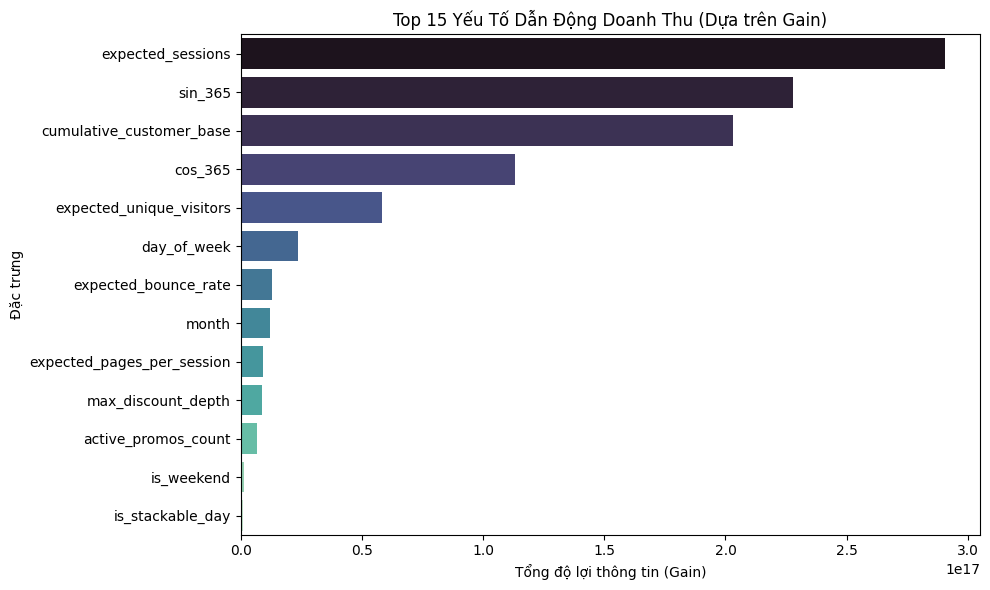

In [13]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CẤU HÌNH THAM SỐ TỐI ƯU (TỪ OPTUNA)
# ==========================================
# Thay thế bộ tham số này bằng cấu hình tốt nhất mà em quét được từ Optuna
# (Bộ cấu hình đã giúp em đẩy R2 vượt mốc 60%)
best_params_revenue = best_params_rev

# ==========================================
# 2. CHỌN TẬP DỮ LIỆU ĐẦU VÀO
# ==========================================
# Ưu tiên dùng tập dữ liệu đã cắt tỉa (pruned) nếu em đã chạy bước feature pruning
try:
    X_train_final = X_train_pruned
    X_test_final = X_test_pruned
    print("Sử dụng tập dữ liệu đã qua Cắt tỉa đặc trưng (Pruned Data).")
except NameError:
    X_train_final = X_train
    X_test_final = X_test
    print("Sử dụng tập dữ liệu Gốc (Full Data).")

# ==========================================
# 3. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH REVENUE
# ==========================================
print("\nKhởi động quá trình huấn luyện mô hình Revenue...")

model_revenue = lgb.LGBMRegressor(**best_params_revenue)

# Train model trên toàn bộ 100% dữ liệu train
model_revenue.fit(X_train_final, y_train_revenue)

print("Huấn luyện hoàn tất!")

# ==========================================
# 4. DỰ BÁO TRÊN TẬP TEST (2023 - 2024)
# ==========================================
print("Đang tiến hành dự báo Revenue cho tương lai...")
preds_revenue_test = model_revenue.predict(X_test_final)

# Xét theo logic thực tế, doanh thu không thể âm, nên ta chặn đáy ở mức 0
preds_revenue_test = np.maximum(0, preds_revenue_test)

# ==========================================
# 5. TRÍCH XUẤT FEATURE IMPORTANCE (CHO BÁO CÁO KỸ THUẬT)
# ==========================================
importance_df = pd.DataFrame({
    'Feature': model_revenue.feature_name_,
    'Importance': model_revenue.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Vẽ biểu đồ Trọng số Đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='mako')
plt.title('Top 15 Yếu Tố Dẫn Động Doanh Thu (Dựa trên Gain)')
plt.xlabel('Tổng độ lợi thông tin (Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show() # Em nhớ lưu ảnh này lại để chèn vào báo cáo LaTeX

In [16]:
import lightgbm as lgb
import numpy as np
import pandas as pd


MULTIPLIER = 1.1
# ==========================================
# 2. XÁC ĐỊNH TẬP DỮ LIỆU ĐẦU VÀO
# ==========================================
# Ưu tiên dùng tập đã cắt tỉa nếu em chạy Cell Cắt tỉa thành công
try:
    X_train_run = X_train_pruned.copy()
    X_test_run = X_test_pruned.copy()
    print("✓ Đang sử dụng dữ liệu ĐÃ CẮT TỈA (Pruned)")
except NameError:
    X_train_run = X_train.copy()
    X_test_run = X_test.copy()
    print("✓ Đang sử dụng dữ liệu GỐC (Full Features)")

# ==========================================
# 3. MÔ HÌNH REVENUE (ÁP DỤNG CÁCH 1: LOG TRANSFORM)
# ==========================================
print("Đang huấn luyện mô hình Revenue với Log Transform...")

# Bước 1: Logarit hóa biến mục tiêu để nén biên độ các ngày siêu sale
y_train_rev_log = np.log1p(y_train_revenue)

model_rev = lgb.LGBMRegressor(**best_params_rev)
# Truyền y_train đã log hóa vào mô hình
model_rev.fit(X_train_run, y_train_rev_log, sample_weight=sample_weights)

# Bước 2: Dự báo trên tập Test (kết quả trả ra đang ở hệ cơ số log)
preds_rev_log = model_rev.predict(X_test_run)

# Bước 3: Chuyển ngược từ Log về giá trị tiền tệ thực tế
preds_rev_raw = np.expm1(preds_rev_log)

# Bước 4: Nhân với hệ số khuếch đại của bạn và chặn đáy 0
preds_rev = np.maximum(0, preds_rev_raw * MULTIPLIER)


# ==========================================
# 4. MÔ HÌNH COGS (ÁP DỤNG TƯƠNG TỰ NHƯ REVENUE)
# ==========================================
print("Đang huấn luyện mô hình COGS với Log Transform...")

y_train_cogs_log = np.log1p(y_train_cogs)

model_cogs = lgb.LGBMRegressor(**best_params_cogs)
model_cogs.fit(X_train_run, y_train_cogs_log, sample_weight=sample_weights)

preds_cogs_log = model_cogs.predict(X_test_run)
preds_cogs_raw = np.expm1(preds_cogs_log)

preds_cogs = np.maximum(0, preds_cogs_raw * MULTIPLIER)
# ==========================================
# 5. XUẤT FILE NỘP BÀI CHUẨN KAGGLE
# ==========================================
print("Đang đóng gói file submission.csv...")

submission = pd.DataFrame({
    'Date': test_dates, # Biến này đã được lưu từ phần gộp Data
    'Revenue': preds_rev,
    'COGS': preds_cogs
})

# Đưa Date về đúng format YYYY-MM-DD
submission['Date'] = pd.to_datetime(submission['Date']).dt.strftime('%Y-%m-%d')

# Đọc file sample_submission gốc để đồng bộ 100% thứ tự dòng
sample_sub = pd.read_csv('sample_submission.csv')

# Khớp thứ tự dòng theo sample_sub
final_submission = pd.merge(sample_sub[['Date']], submission, on='Date', how='left')

# Điền 0 nếu có bất kỳ lỗi rớt ngày nào để Kaggle không báo lỗi (Safety Check)
final_submission = final_submission.fillna(0)

# Xuất file
final_submission.to_csv('submission.csv', index=False)
print("★ Xong! File 'submission.csv' đã sẵn sàng để upload lên Kaggle.")

✓ Đang sử dụng dữ liệu ĐÃ CẮT TỈA (Pruned)
Đang huấn luyện mô hình Revenue với Log Transform...
Đang huấn luyện mô hình COGS với Log Transform...
Đang đóng gói file submission.csv...
★ Xong! File 'submission.csv' đã sẵn sàng để upload lên Kaggle.


In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd

# ==========================================
# 1. CHUẨN BỊ TẬP DỮ LIỆU FINAL (100% TRAIN DATA)
# ==========================================
# Sử dụng tập đã cắt tỉa (Pruned) nếu có, ngược lại dùng bản gốc
X_train_final = X_train_pruned if 'X_train_pruned' in locals() else X_train
X_test_final = X_test_pruned if 'X_test_pruned' in locals() else X_test

# Xác định biến mục tiêu (Sử dụng tập đã Downscale nếu bạn đã chạy code hạ scale trước đó)
y_train_rev_final = y_train_rev_adj if 'y_train_rev_adj' in locals() else y_train_revenue
y_train_cogs_final = y_train_cogs_adj if 'y_train_cogs_adj' in locals() else y_train_cogs

# Hệ số nhân hậu xử lý (Nếu bạn muốn tăng 5% dự báo thì đặt 1.05, nếu giữ nguyên thì để 1.0)
MULTIPLIER = 1.4

# ==========================================
# 2. HUẤN LUYỆN MÔ HÌNH REVENUE (VỚI LOG TRANSFORM)
# ==========================================
print("Đang huấn luyện mô hình REVENUE cuối cùng (trên 100% data)...")

# Logarit hóa biến mục tiêu
y_train_rev_log = np.log1p(y_train_rev_final)

# Khởi tạo mô hình với bộ tham số tốt nhất
model_rev_final = lgb.LGBMRegressor(**best_params_rev)

# Huấn luyện (Không cần eval_set hay early_stopping ở bước này nữa)
model_rev_final.fit(X_train_final, y_train_rev_log)

# Dự báo tập Test (Kết quả đang ở dạng Log)
preds_rev_log = model_rev_final.predict(X_test_final)

# Chuyển ngược về số tiền thực tế (expm1), nhân hệ số và chặn đáy 0
preds_rev = np.maximum(0, np.expm1(preds_rev_log) * MULTIPLIER)


# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH COGS (VỚI LOG TRANSFORM)
# ==========================================
print("Đang huấn luyện mô hình COGS cuối cùng (trên 100% data)...")

y_train_cogs_log = np.log1p(y_train_cogs_final)

model_cogs_final = lgb.LGBMRegressor(**best_params_cogs)
model_cogs_final.fit(X_train_final, y_train_cogs_log)

preds_cogs_log = model_cogs_final.predict(X_test_final)
preds_cogs = np.maximum(0, np.expm1(preds_cogs_log) * MULTIPLIER)


# ==========================================
# 4. ĐÓNG GÓI VÀ XUẤT FILE NỘP BÀI (KAGGLE SUBMISSION)
# ==========================================
print("Đang đóng gói file submission.csv...")

# Khởi tạo DataFrame kết quả
submission = pd.DataFrame({
    'Date': test_dates, # test_dates được bạn lưu lại lúc drop cột Date ở trên
    'Revenue': preds_rev,
    'COGS': preds_cogs
})

# Chuyển Date về đúng định dạng YYYY-MM-DD
submission['Date'] = pd.to_datetime(submission['Date']).dt.strftime('%Y-%m-%d')

# Đọc file sample_submission gốc để đảm bảo thứ tự dòng đồng bộ 100%
sample_sub = pd.read_csv('sample_submission.csv')

# Khớp thứ tự dòng (Left Join) để loại bỏ rủi ro sai lệch dòng trên Kaggle
final_submission = pd.merge(sample_sub[['Date']], submission, on='Date', how='left')

# Điền số 0 cho những ngày không có dự báo (nếu có) để tránh lỗi chấm điểm
final_submission = final_submission.fillna(0)

# Xuất ra file CSV
final_submission.to_csv('submission.csv', index=False)
print("★ Hoàn tất! File 'submission.csv' đã sẵn sàng để nộp lên hệ thống.")

Đang huấn luyện mô hình REVENUE cuối cùng (trên 100% data)...
Đang huấn luyện mô hình COGS cuối cùng (trên 100% data)...
Đang đóng gói file submission.csv...
★ Hoàn tất! File 'submission.csv' đã sẵn sàng để nộp lên hệ thống.


--- Descriptive Stats: Revenue ---
        Revenue_New  Revenue_Best
count  5.480000e+02  5.480000e+02
mean   4.913973e+06  4.616867e+06
std    2.127535e+06  2.333540e+06
min    1.434667e+06  1.373891e+06
25%    3.124975e+06  2.831448e+06
50%    4.728852e+06  4.098495e+06
75%    6.167230e+06  5.721849e+06
max    1.212651e+07  1.482447e+07

--- Descriptive Stats: COGS ---
           COGS_New     COGS_Best
count  5.480000e+02  5.480000e+02
mean   4.088405e+06  3.929090e+06
std    1.666804e+06  1.996735e+06
min    1.252911e+06  1.074318e+06
25%    2.697163e+06  2.437954e+06
50%    3.983008e+06  3.558643e+06
75%    5.122721e+06  4.706785e+06
max    1.151358e+07  1.213713e+07

Revenue Correlation: 0.9450
Revenue MAE: 589,627.68
Revenue RMSE: 821,816.78
COGS Correlation: 0.9273

--- Top 10 Days with Highest Revenue Difference ---
          Date   Revenue_New  Revenue_Best      Diff_Rev
453 2024-03-29  1.117955e+07  6.676595e+06  4.502952e+06
458 2024-04-03  5.010743e+06  8.905152e+06 -3.8944

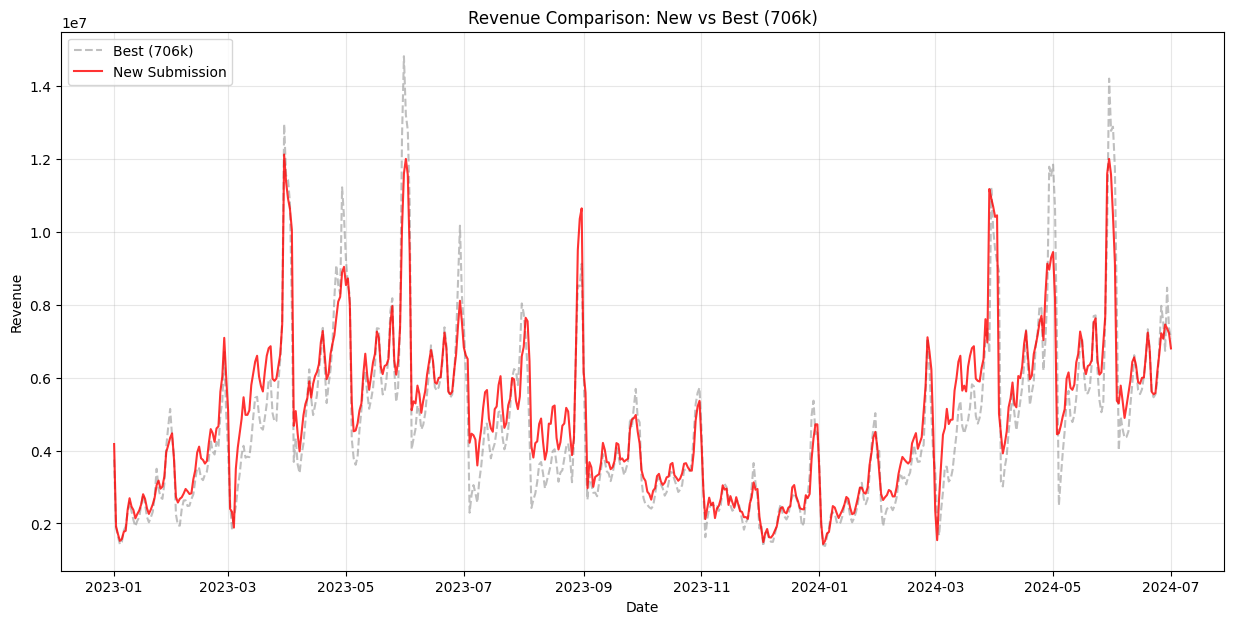

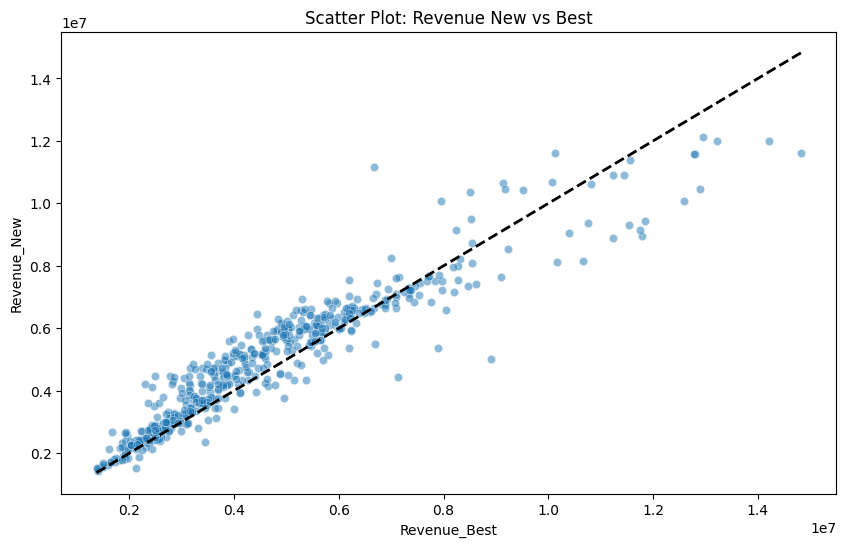

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the files
sub_new = pd.read_csv('submission.csv')
sub_best = pd.read_csv('submission_best_706k.csv')

# Ensure Date is datetime
sub_new['Date'] = pd.to_datetime(sub_new['Date'])
sub_best['Date'] = pd.to_datetime(sub_best['Date'])

# Merge to compare
df_comp = pd.merge(sub_new, sub_best, on='Date', suffixes=('_New', '_Best'))

# Basic Stats
stats_rev = df_comp[['Revenue_New', 'Revenue_Best']].describe()
stats_cogs = df_comp[['COGS_New', 'COGS_Best']].describe()

# Metrics
corr_rev = df_comp['Revenue_New'].corr(df_comp['Revenue_Best'])
mae_rev = np.mean(np.abs(df_comp['Revenue_New'] - df_comp['Revenue_Best']))
rmse_rev = np.sqrt(np.mean((df_comp['Revenue_New'] - df_comp['Revenue_Best'])**2))

corr_cogs = df_comp['COGS_New'].corr(df_comp['COGS_Best'])
mae_cogs = np.mean(np.abs(df_comp['COGS_New'] - df_comp['COGS_Best']))

# Differences
df_comp['Diff_Rev'] = df_comp['Revenue_New'] - df_comp['Revenue_Best']
df_comp['Abs_Diff_Rev'] = df_comp['Diff_Rev'].abs()
top_diffs = df_comp.sort_values('Abs_Diff_Rev', ascending=False).head(10)

# Print results
print("--- Descriptive Stats: Revenue ---")
print(stats_rev)
print("\n--- Descriptive Stats: COGS ---")
print(stats_cogs)
print(f"\nRevenue Correlation: {corr_rev:.4f}")
print(f"Revenue MAE: {mae_rev:,.2f}")
print(f"Revenue RMSE: {rmse_rev:,.2f}")
print(f"COGS Correlation: {corr_cogs:.4f}")

print("\n--- Top 10 Days with Highest Revenue Difference ---")
print(top_diffs[['Date', 'Revenue_New', 'Revenue_Best', 'Diff_Rev']])

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(df_comp['Date'], df_comp['Revenue_Best'], label='Best (706k)', color='gray', alpha=0.5, linestyle='--')
plt.plot(df_comp['Date'], df_comp['Revenue_New'], label='New Submission', color='red', alpha=0.8)
plt.title('Revenue Comparison: New vs Best (706k)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('revenue_comparison.png')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_comp, x='Revenue_Best', y='Revenue_New', alpha=0.5)
plt.plot([df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         [df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         'k--', lw=2)
plt.title('Scatter Plot: Revenue New vs Best')
plt.savefig('revenue_scatter.png')